# Notebook 07 — Evaluación y selección de modelos de regresión

En este notebook estudiaremos cómo evaluar y comparar modelos de regresión utilizando distintas métricas.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- construir un modelo base;
- calcular MAE, MSE, RMSE, MAPE y \(R^2\);
- interpretar cada métrica en el contexto del problema;
- analizar la sensibilidad de las métricas a observaciones atípicas;
- comparar varios modelos sobre el mismo conjunto de prueba;
- revisar residuos y errores individuales;
- reconocer que distintas métricas pueden producir rankings diferentes;
- seleccionar un modelo considerando desempeño, estabilidad e interpretabilidad.

Usaremos datos sintéticos con ruido, no linealidad y algunas observaciones atípicas.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación del dataset

La variable objetivo combinará:

- una relación lineal;
- una interacción;
- un efecto no lineal;
- ruido aleatorio;
- algunas observaciones atípicas.

Esto permitirá que distintos modelos tengan ventajas y limitaciones diferentes.

In [2]:
n_samples = 650

x1 = rng.normal(0, 1, size=n_samples)
x2 = rng.normal(0, 1, size=n_samples)
x3 = rng.uniform(-3, 3, size=n_samples)
x4 = rng.normal(0, 1, size=n_samples)

X = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "x3": x3,
    "x4": x4,
})

y = (
    25
    + 8 * x1
    - 5 * x2
    + 3 * x1 * x2
    + 7 * np.sin(x3)
    + 2 * x4
    + rng.normal(0, 3.5, size=n_samples)
)

# Introducimos algunos outliers en la variable objetivo
outlier_indices = rng.choice(
    n_samples,
    size=18,
    replace=False,
)

y[outlier_indices] += rng.normal(
    0,
    35,
    size=len(outlier_indices),
)

data = X.copy()
data["y"] = y
data["es_outlier_generado"] = False
data.loc[outlier_indices, "es_outlier_generado"] = True

data.head()


,x1,x2,x3,x4,y,es_outlier_generado
0,0.3047,1.8478,2.2689,-2.1804,23.3851,False
1,-1.0400,-0.1742,-0.7532,-0.3797,6.9185,False
2,0.7505,1.6679,-2.3934,-1.8029,15.1716,False
3,0.9406,-1.1037,1.8658,-0.7522,44.4547,False
4,-1.9510,0.5873,-0.1094,-0.9091,1.4396,False


In [3]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
x1,650.0000,-0.0306,0.9771,-2.9645,-0.6941,-0.0333,0.5805,2.9139
x2,650.0000,-0.0208,1.0009,-3.6484,-0.6756,0.0073,0.6336,3.1789
x3,650.0000,0.0776,1.7418,-2.9966,-1.5213,-0.0018,1.6427,2.9930
x4,650.0000,0.0260,1.0103,-3.0638,-0.6314,0.0652,0.6593,2.8574
y,650.0000,24.5450,13.5475,-57.6643,17.7642,25.5172,33.2436,76.7524


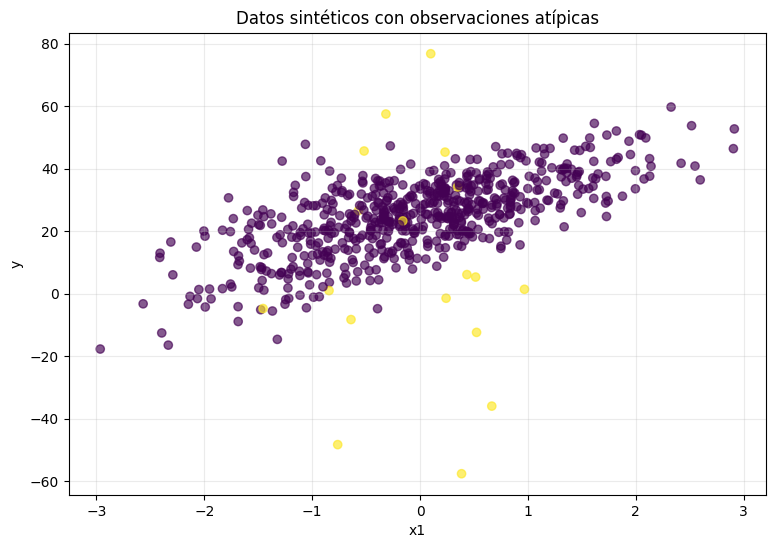

In [4]:
plt.figure(figsize=(9, 6))
plt.scatter(
    data["x1"],
    data["y"],
    c=data["es_outlier_generado"].astype(int),
    alpha=0.65,
)
plt.xlabel("x1")
plt.ylabel("y")
plt.title("Datos sintéticos con observaciones atípicas")
plt.grid(alpha=0.25)
plt.show()


## 3. Split de entrenamiento y prueba

Todos los modelos se evaluarán sobre exactamente las mismas observaciones de prueba.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")


Entrenamiento: (487, 4)
Prueba: (163, 4)


## 4. Métricas de regresión

### MAE

\[
MAE=
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\widehat{y}_i|.
\]

Se interpreta en las mismas unidades de \(y\).

### MSE

\[
MSE=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\widehat{y}_i)^2.
\]

Penaliza fuertemente los errores grandes.

### RMSE

\[
RMSE=\sqrt{MSE}.
\]

También se interpreta en las unidades originales.

### MAPE

\[
MAPE=
\frac{1}{n}
\sum_{i=1}^{n}
\left|
\frac{y_i-\widehat{y}_i}{y_i}
\right|.
\]

Se expresa como proporción o porcentaje, pero presenta problemas cuando los valores reales son cero o cercanos a cero.

### \(R^2\)

Compara el modelo con una predicción constante basada en la media.

In [6]:
def regression_metrics(y_true, y_pred):
    """Calcula métricas básicas de regresión."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }


## 5. Modelo base

Un modelo debe compararse contra una estrategia sencilla.

Usaremos `DummyRegressor`, que siempre predice la media del conjunto de entrenamiento.

In [7]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

pd.DataFrame(
    regression_metrics(
        y_test,
        baseline_predictions,
    ).items(),
    columns=["Métrica", "Valor"],
)


,Métrica,Valor
0,MAE,11.3125
1,MSE,237.9480
2,RMSE,15.4256
3,MAPE,1.2892
4,R²,-0.0026


Si un modelo complejo no supera claramente este baseline, su utilidad es cuestionable.

## 6. Modelos candidatos

Compararemos:

- baseline;
- regresión lineal;
- Ridge;
- regresión polinomial de grado 2;
- KNN;
- árbol de decisión.

No estamos realizando todavía selección formal de hiperparámetros. Usaremos configuraciones razonables con fines didácticos.

In [8]:
models = {
    "Baseline media": DummyRegressor(
        strategy="mean",
    ),
    "Regresión lineal": LinearRegression(),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10)),
    ]),
    "Regresión polinomial": Pipeline([
        (
            "polynomial",
            PolynomialFeatures(
                degree=2,
                include_bias=False,
            ),
        ),
        ("linear", LinearRegression()),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsRegressor(
                n_neighbors=12,
                weights="distance",
            ),
        ),
    ]),
    "Árbol": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    ),
}


In [9]:
evaluation_rows = []
predictions_by_model = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    predictions_by_model[model_name] = test_prediction

    train_metrics = regression_metrics(
        y_train,
        train_prediction,
    )
    test_metrics = regression_metrics(
        y_test,
        test_prediction,
    )

    evaluation_rows.append({
        "Modelo": model_name,
        "RMSE train": train_metrics["RMSE"],
        "RMSE test": test_metrics["RMSE"],
        "MAE test": test_metrics["MAE"],
        "MSE test": test_metrics["MSE"],
        "MAPE test": test_metrics["MAPE"],
        "R² test": test_metrics["R²"],
    })

evaluation_table = pd.DataFrame(
    evaluation_rows
)

evaluation_table.sort_values("RMSE test")


,Modelo,RMSE train,RMSE test,MAE test,MSE test,MAPE test,R² test
3,Regresión polinomial,6.8632,10.5422,4.7793,111.1376,0.3640,0.5317
4,KNN,0.0000,11.0897,5.4947,122.9824,0.3931,0.4818
2,Ridge,7.3121,11.1622,5.7443,124.5941,0.4459,0.4750
1,Regresión lineal,7.3094,11.1773,5.7190,124.9321,0.4352,0.4736
5,Árbol,6.5314,11.6270,7.1817,135.1861,0.5231,0.4304
0,Baseline media,12.8452,15.4256,11.3125,237.9480,1.2892,-0.0026


## 7. Ranking según la métrica

No existe una métrica universalmente mejor. La elección debe reflejar el costo del error en el problema real.

In [10]:
ranking_rmse = (
    evaluation_table
    .sort_values("RMSE test")
    [["Modelo", "RMSE test"]]
    .reset_index(drop=True)
)

ranking_mae = (
    evaluation_table
    .sort_values("MAE test")
    [["Modelo", "MAE test"]]
    .reset_index(drop=True)
)

ranking_r2 = (
    evaluation_table
    .sort_values("R² test", ascending=False)
    [["Modelo", "R² test"]]
    .reset_index(drop=True)
)

print("Ranking por RMSE")
display(ranking_rmse)

print("Ranking por MAE")
display(ranking_mae)

print("Ranking por R²")
display(ranking_r2)


Ranking por RMSE


,Modelo,RMSE test
0,Regresión polinomial,10.5422
1,KNN,11.0897
2,Ridge,11.1622
3,Regresión lineal,11.1773
4,Árbol,11.6270
5,Baseline media,15.4256


Ranking por MAE


,Modelo,MAE test
0,Regresión polinomial,4.7793
1,KNN,5.4947
2,Regresión lineal,5.7190
3,Ridge,5.7443
4,Árbol,7.1817
5,Baseline media,11.3125


Ranking por R²


,Modelo,R² test
0,Regresión polinomial,0.5317
1,KNN,0.4818
2,Ridge,0.4750
3,Regresión lineal,0.4736
4,Árbol,0.4304
5,Baseline media,-0.0026


Dos modelos pueden cambiar de posición cuando cambia la métrica, especialmente si uno comete pocos errores grandes y otro muchos errores moderados.

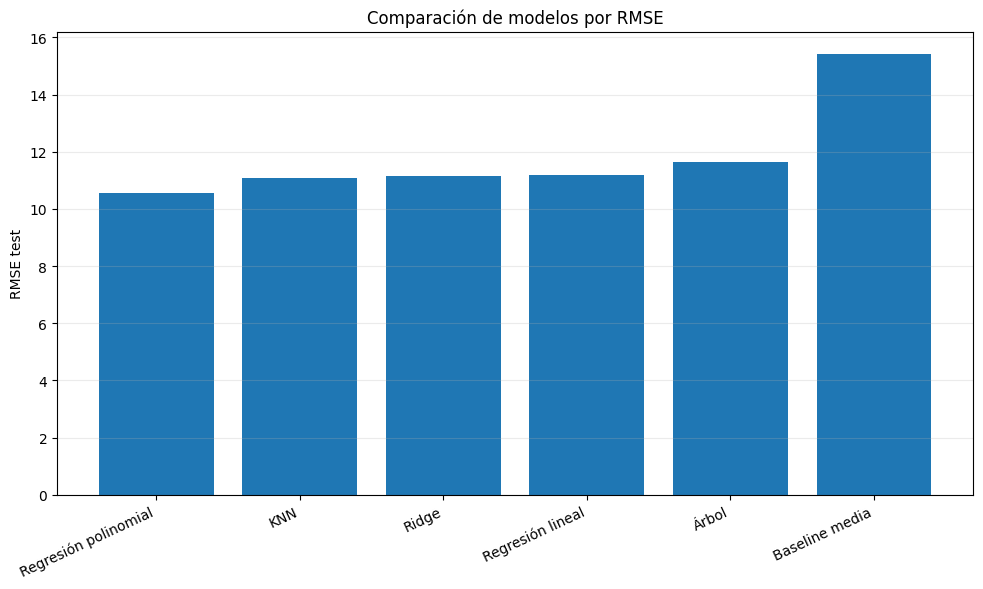

In [11]:
ordered_rmse = evaluation_table.sort_values(
    "RMSE test"
)

plt.figure(figsize=(10, 6))
plt.bar(
    ordered_rmse["Modelo"],
    ordered_rmse["RMSE test"],
)
plt.ylabel("RMSE test")
plt.title("Comparación de modelos por RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 8. Brecha entre entrenamiento y prueba

Una gran diferencia entre el error de entrenamiento y prueba puede indicar overfitting.

In [12]:
evaluation_table["Brecha RMSE"] = (
    evaluation_table["RMSE test"]
    - evaluation_table["RMSE train"]
)

evaluation_table[
    [
        "Modelo",
        "RMSE train",
        "RMSE test",
        "Brecha RMSE",
    ]
].sort_values("Brecha RMSE", ascending=False)


,Modelo,RMSE train,RMSE test,Brecha RMSE
4,KNN,0.0000,11.0897,11.0897
5,Árbol,6.5314,11.6270,5.0956
1,Regresión lineal,7.3094,11.1773,3.8679
2,Ridge,7.3121,11.1622,3.8501
3,Regresión polinomial,6.8632,10.5422,3.6790
0,Baseline media,12.8452,15.4256,2.5803


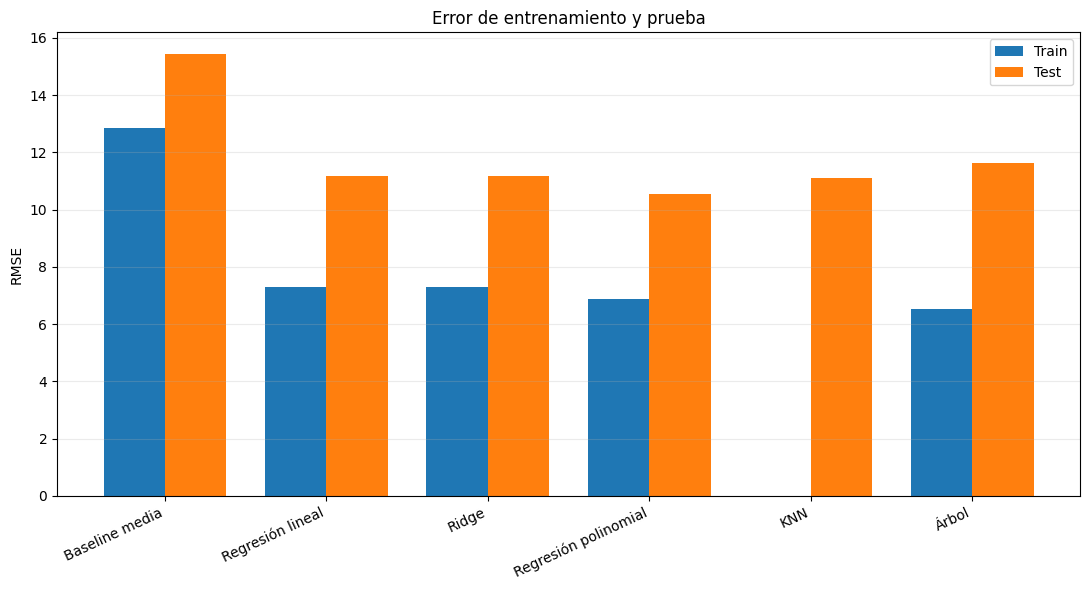

In [13]:
positions = np.arange(len(evaluation_table))
width = 0.38

plt.figure(figsize=(11, 6))

plt.bar(
    positions - width / 2,
    evaluation_table["RMSE train"],
    width=width,
    label="Train",
)

plt.bar(
    positions + width / 2,
    evaluation_table["RMSE test"],
    width=width,
    label="Test",
)

plt.xticks(
    positions,
    evaluation_table["Modelo"],
    rotation=25,
    ha="right",
)
plt.ylabel("RMSE")
plt.title("Error de entrenamiento y prueba")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 9. Valores observados contra predichos

Una forma visual de evaluar un modelo consiste en comparar \(y\) con \(\widehat{y}\).

Un modelo perfecto colocaría todos los puntos sobre la diagonal.

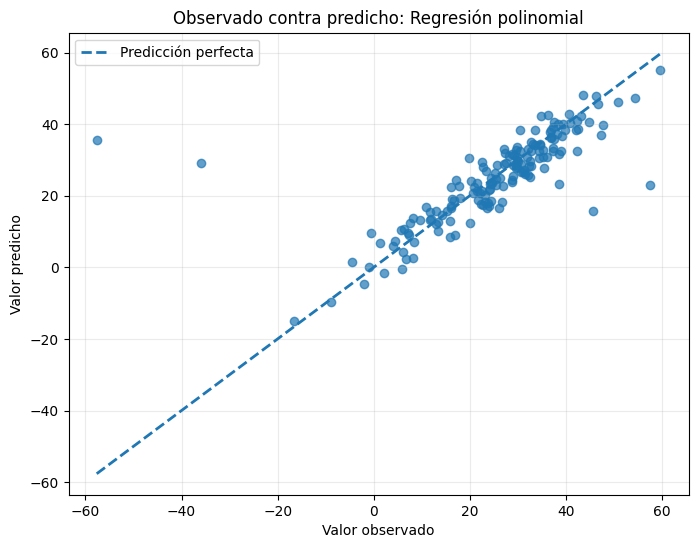

In [14]:
best_model_name = ranking_rmse.iloc[0]["Modelo"]
best_predictions = predictions_by_model[
    best_model_name
]

minimum_value = min(
    y_test.min(),
    best_predictions.min(),
)
maximum_value = max(
    y_test.max(),
    best_predictions.max(),
)

plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    best_predictions,
    alpha=0.7,
)
plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Predicción perfecta",
)
plt.xlabel("Valor observado")
plt.ylabel("Valor predicho")
plt.title(
    f"Observado contra predicho: "
    f"{best_model_name}"
)
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 10. Análisis de residuos del mejor modelo

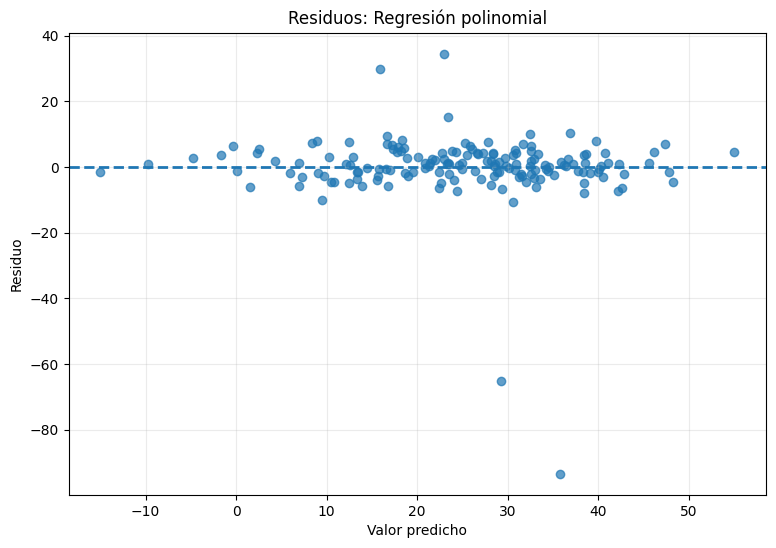

In [15]:
best_residuals = y_test - best_predictions

plt.figure(figsize=(9, 6))
plt.scatter(
    best_predictions,
    best_residuals,
    alpha=0.7,
)
plt.axhline(
    0,
    linestyle="--",
    linewidth=2,
)
plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title(
    f"Residuos: {best_model_name}"
)
plt.grid(alpha=0.25)
plt.show()


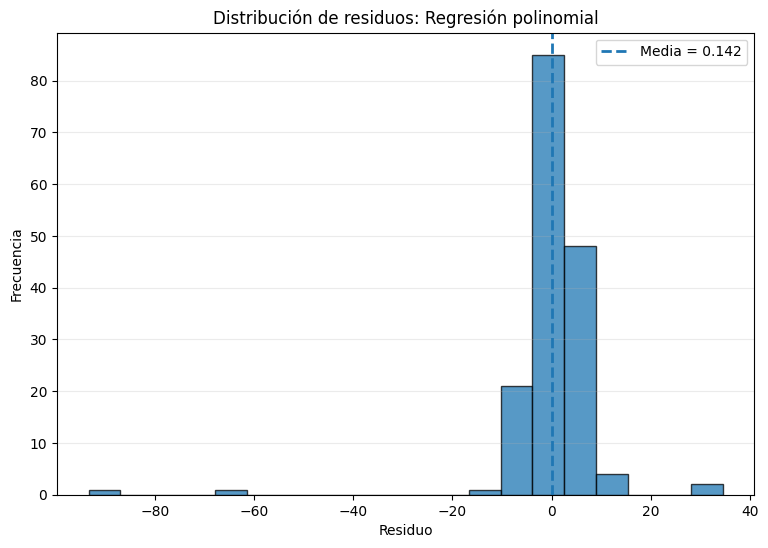

In [16]:
plt.figure(figsize=(9, 6))
plt.hist(
    best_residuals,
    bins=20,
    edgecolor="black",
    alpha=0.75,
)
plt.axvline(
    best_residuals.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media = {best_residuals.mean():.3f}",
)
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title(
    f"Distribución de residuos: "
    f"{best_model_name}"
)
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## 11. Identificación de los errores más grandes

Las métricas agregadas pueden ocultar observaciones problemáticas.

In [17]:
error_analysis = X_test.copy()
error_analysis["y_real"] = y_test
error_analysis["y_predicha"] = best_predictions
error_analysis["residuo"] = (
    error_analysis["y_real"]
    - error_analysis["y_predicha"]
)
error_analysis["error_absoluto"] = (
    error_analysis["residuo"].abs()
)
error_analysis["error_cuadrado"] = (
    error_analysis["residuo"] ** 2
)

error_analysis.sort_values(
    "error_absoluto",
    ascending=False,
).head(15)


,x1,x2,x3,x4,y_real,y_predicha,residuo,error_absoluto,error_cuadrado
550,0.3850,-1.3225,2.1031,-0.7620,-57.6643,35.7199,-93.3842,93.3842,"8,720.6134"
90,0.6654,1.0017,1.6792,-0.3969,-36.0249,29.2109,-65.2358,65.2358,"4,255.7067"
7,-0.3162,0.1774,0.6433,0.0564,57.4613,22.9440,34.5173,34.5173,"1,191.4443"
329,-0.5183,0.4438,-1.6340,0.6313,45.6166,15.8847,29.7320,29.7320,883.9893
404,0.5212,-1.3773,-2.8369,-0.6918,38.5776,23.4132,15.1643,15.1643,229.9574
320,0.7824,-0.2828,-0.6048,-0.1950,19.8161,30.5813,-10.7651,10.7651,115.8882
56,-0.2751,-0.9106,2.0082,2.2142,47.2469,36.8810,10.3658,10.3658,107.4502
277,-1.1124,0.4138,-1.7216,0.0927,-0.5368,9.4742,-10.0110,10.0110,100.2208
174,-1.2779,-1.8618,0.7609,0.1075,42.4003,32.4244,9.9759,9.9759,99.5179
447,-0.3315,0.4946,2.0524,-1.9608,26.0745,16.6800,9.3944,9.3944,88.2553


Revisar los errores más grandes ayuda a detectar:

- outliers;
- subgrupos mal representados;
- variables faltantes;
- errores de captura;
- regiones donde el modelo no generaliza.

## 12. Sensibilidad de MAE y RMSE a outliers

Construiremos dos vectores de errores con el mismo comportamiento general, pero uno tendrá un error extremo.

In [18]:
regular_errors = np.array([
    2, -3, 1, 4, -2, 3, -1, 2, -4, 1
])

errors_with_outlier = regular_errors.copy()
errors_with_outlier[-1] = 30

outlier_metric_comparison = pd.DataFrame({
    "Escenario": [
        "Errores regulares",
        "Con error extremo",
    ],
    "MAE": [
        np.mean(np.abs(regular_errors)),
        np.mean(np.abs(errors_with_outlier)),
    ],
    "RMSE": [
        np.sqrt(np.mean(regular_errors ** 2)),
        np.sqrt(np.mean(errors_with_outlier ** 2)),
    ],
})

outlier_metric_comparison


,Escenario,MAE,RMSE
0,Errores regulares,2.3000,2.5495
1,Con error extremo,5.2000,9.8184


RMSE aumenta con mayor intensidad porque eleva los errores al cuadrado.

Esto puede ser deseable cuando los errores grandes tienen un costo especialmente alto.

## 13. Precauciones con MAPE

MAPE puede volverse inestable cuando \(y_i\) es cero o cercano a cero.

In [19]:
y_small = np.array([
    100.0,
    50.0,
    10.0,
    1.0,
    0.1,
])

y_small_pred = np.array([
    90.0,
    45.0,
    8.0,
    0.5,
    0.2,
])

mape_example = pd.DataFrame({
    "y_real": y_small,
    "y_predicha": y_small_pred,
})

mape_example["error_absoluto"] = np.abs(
    mape_example["y_real"]
    - mape_example["y_predicha"]
)

mape_example["error_porcentual_absoluto"] = (
    mape_example["error_absoluto"]
    / np.abs(mape_example["y_real"])
)

mape_example


,y_real,y_predicha,error_absoluto,error_porcentual_absoluto
0,100.0000,90.0000,10.0000,0.1000
1,50.0000,45.0000,5.0000,0.1000
2,10.0000,8.0000,2.0000,0.2000
3,1.0000,0.5000,0.5000,0.5000
4,0.1000,0.2000,0.1000,1.0000


In [20]:
print(
    "MAPE:",
    mean_absolute_percentage_error(
        y_small,
        y_small_pred,
    ),
)


MAPE: 0.38


Una diferencia absoluta pequeña puede convertirse en un error porcentual enorme cuando el denominador es muy pequeño.

Por eso MAPE no debe utilizarse automáticamente en todos los problemas.

## 14. Selección de modelo con criterios múltiples

El modelo con menor RMSE no necesariamente es la mejor decisión final.

También pueden importar:

- interpretabilidad;
- velocidad de entrenamiento;
- velocidad de predicción;
- estabilidad;
- facilidad de implementación;
- capacidad de extrapolación;
- restricciones regulatorias;
- costo de mantenimiento.

In [21]:
selection_summary = evaluation_table[
    [
        "Modelo",
        "MAE test",
        "RMSE test",
        "MAPE test",
        "R² test",
        "Brecha RMSE",
    ]
].copy()

selection_summary.sort_values("RMSE test")


,Modelo,MAE test,RMSE test,MAPE test,R² test,Brecha RMSE
3,Regresión polinomial,4.7793,10.5422,0.3640,0.5317,3.6790
4,KNN,5.4947,11.0897,0.3931,0.4818,11.0897
2,Ridge,5.7443,11.1622,0.4459,0.4750,3.8501
1,Regresión lineal,5.7190,11.1773,0.4352,0.4736,3.8679
5,Árbol,7.1817,11.6270,0.5231,0.4304,5.0956
0,Baseline media,11.3125,15.4256,1.2892,-0.0026,2.5803


### Ejemplo de decisión

- Si los errores extremos son muy costosos, RMSE puede dominar la decisión.
- Si importa el error típico en unidades originales, MAE puede ser más intuitivo.
- Si se requiere explicar el modelo, una regresión lineal puede preferirse aunque pierda ligeramente en desempeño.
- Si el problema exige extrapolación, KNN y árboles pueden ser menos apropiados.

## 15. Errores frecuentes

1. Evaluar en entrenamiento.
2. Comparar modelos sobre distintos splits.
3. Elegir una métrica sin considerar el problema.
4. Interpretar \(R^2\) como causalidad.
5. Suponer que un \(R^2\) negativo es imposible.
6. Usar MAPE con valores cercanos a cero.
7. Ignorar la dispersión de los residuos.
8. Seleccionar únicamente por una décima de diferencia.
9. Usar el test repetidamente para tomar decisiones.
10. No comparar contra un baseline.

## 16. Experimentos sugeridos

### Experimento 1

Elimina las observaciones atípicas y repite la comparación.

### Experimento 2

Agrega más outliers y analiza el ranking por MAE y RMSE.

### Experimento 3

Evalúa un árbol sin restricciones y observa la brecha train-test.

### Experimento 4

Cambia el número de vecinos de KNN.

### Experimento 5

Crea una variable objetivo con valores cercanos a cero y analiza MAPE.

### Experimento 6

Compara el mejor modelo contra una regresión lineal solo en términos de interpretabilidad y costo.

### Experimento 7

Repite el split con diferentes semillas y observa si el ranking cambia.

### Experimento 8

Define una función de costo de negocio donde los errores positivos y negativos tengan costos diferentes.

## 17. Resumen

En este notebook:

- construimos un baseline;
- calculamos MAE, MSE, RMSE, MAPE y \(R^2\);
- comparamos varios modelos;
- analizamos la brecha entre train y test;
- revisamos residuos y errores extremos;
- estudiamos la sensibilidad de MAE y RMSE;
- discutimos las limitaciones de MAPE;
- seleccionamos modelos con criterios cuantitativos y prácticos.

La evaluación no consiste únicamente en calcular métricas. Consiste en elegir evidencia que represente correctamente el costo y el objetivo del problema.